# 第9章  文件内容操作


## 9.1  文件操作基本知识


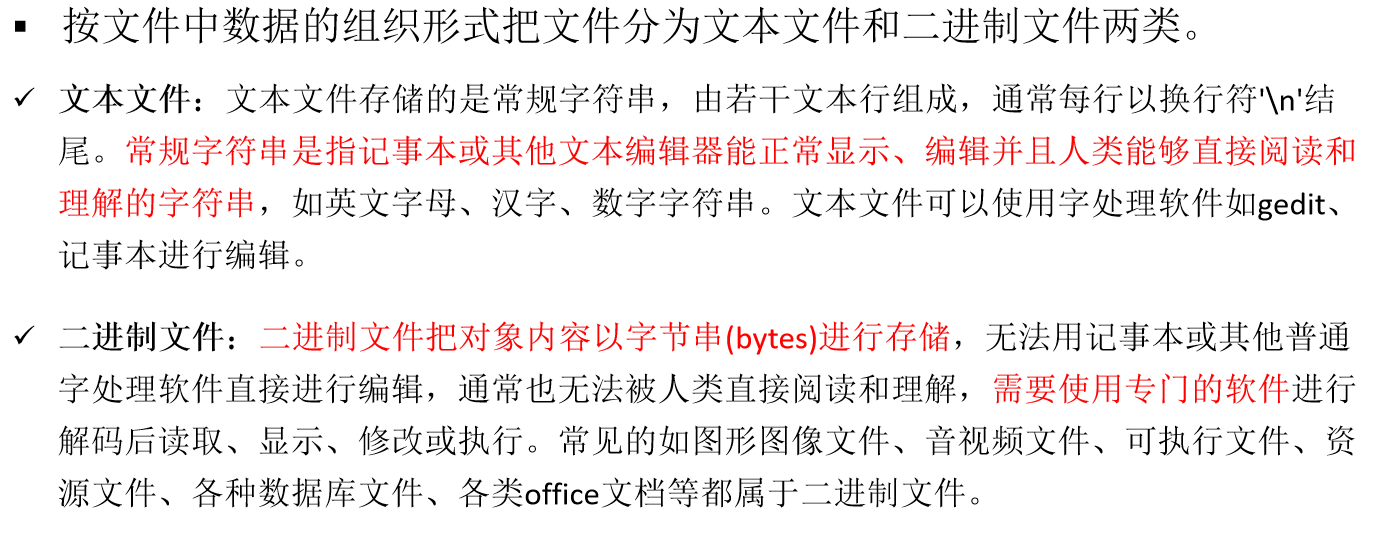

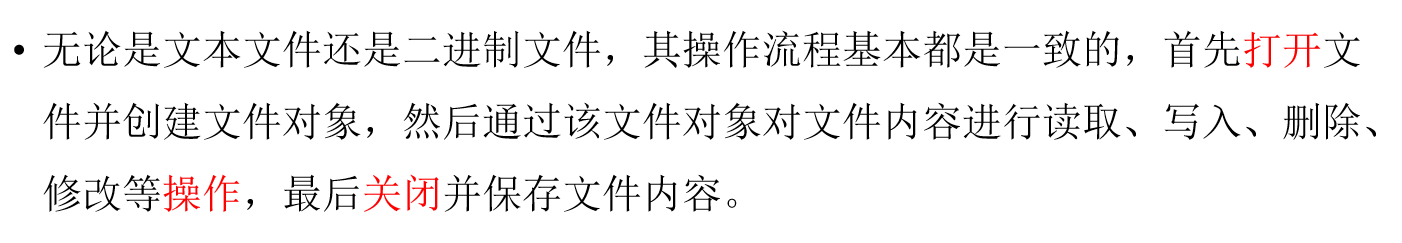

## 9.1.1 内置函数open()

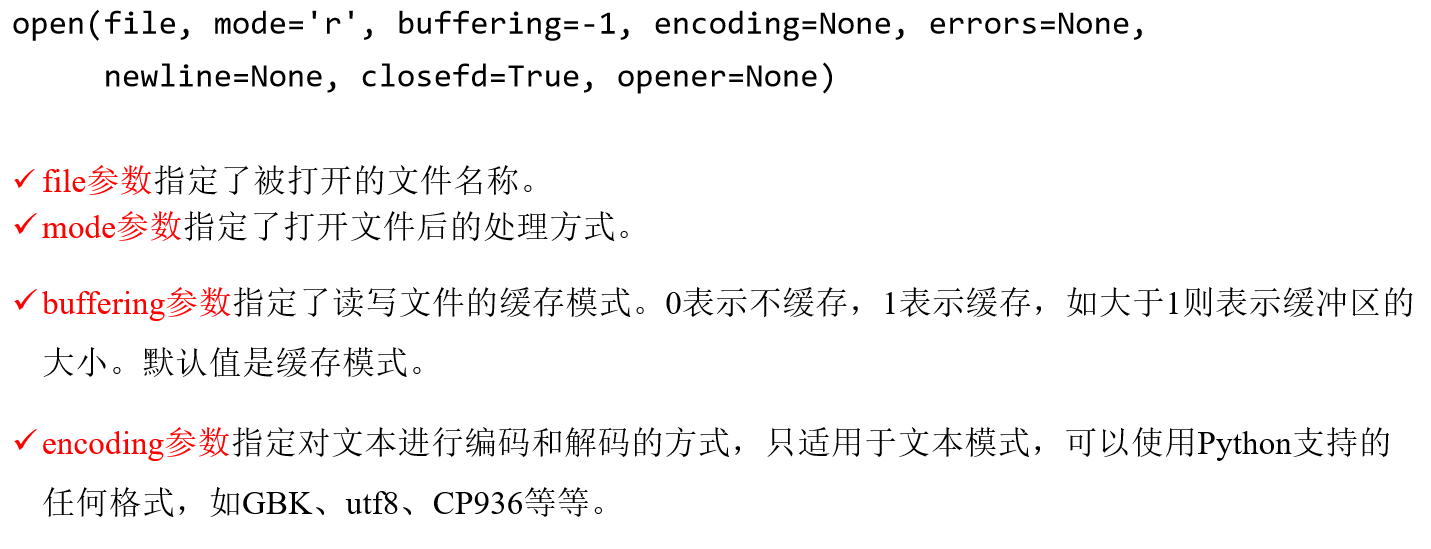

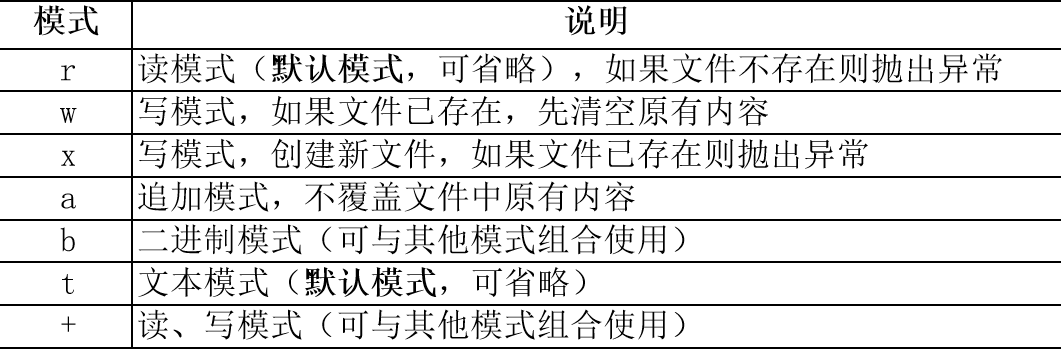

>## r : 可读, 不可写, 必须存在, 可在任意位置读取, 文件指针自由移动

>## w : 不可读, 可写, 可以不存在, 若存在则必会擦掉原有内容从头写

>## a : 不可读, 可写, 可以不存在, 必不能修改原有内容, 只能在结尾追加写

>## r+ : 可读可写, 必须存在, 可在任意位置读写, 读与写共用同一个指针

>## w+ : 可读可写, 可以不存在, 必会擦掉原有内容从头写

>## a+ : 可读可写, 可以不存在, 必不能修改原有内容, 只能在结尾追加写
 

1. r可读, w/a可写, 带+的可读可写

2. r/r+, 文件指针自由移动, 其他的, 写时文件指针会移动到结尾 (也就是不能对非空白内容进行覆写)

3. w/w+, 会擦掉文件原有内容, 而 a/a+ 不会擦掉原有内容, 只会追加

In [293]:
s=['Hello world!','Happy New Year 2025!']
f1 = open('test1.txt','w+')
f1.writelines(s)
f1.close()

In [294]:
f1 = open('test1.txt','r')
f1.readlines()

['Hello world!Happy New Year 2025!']

In [295]:
f1 = open('test1.txt','w')# 创建新文件，如果已经存在，清空原有内容
f1.close()
f1 = open('test1.txt','r')
f1.readlines()

[]

In [296]:
s='Hello world!'
f1 = open('test1.txt','r+')
f1.write(s)

12

In [66]:
f1.close()

In [308]:
s='Hello world!'
f1 = open('test2.txt','w+')
f1.write(s)

12

In [309]:
f1.seek(3)
f1.write(s)
f1.close()

In [310]:
#help(f1.read())

In [311]:
f1 = open('test2.txt','r')
for line in f1:
    print(line)

HelHello world!


In [312]:
f1 = open('test2.txt','a+')

In [313]:
f1.write('jiangnan university')
f1.close()

In [314]:
f1 = open('test2.txt','r')
f1.readlines()

['HelHello world!jiangnan university']

In [315]:
f1.tell()

34

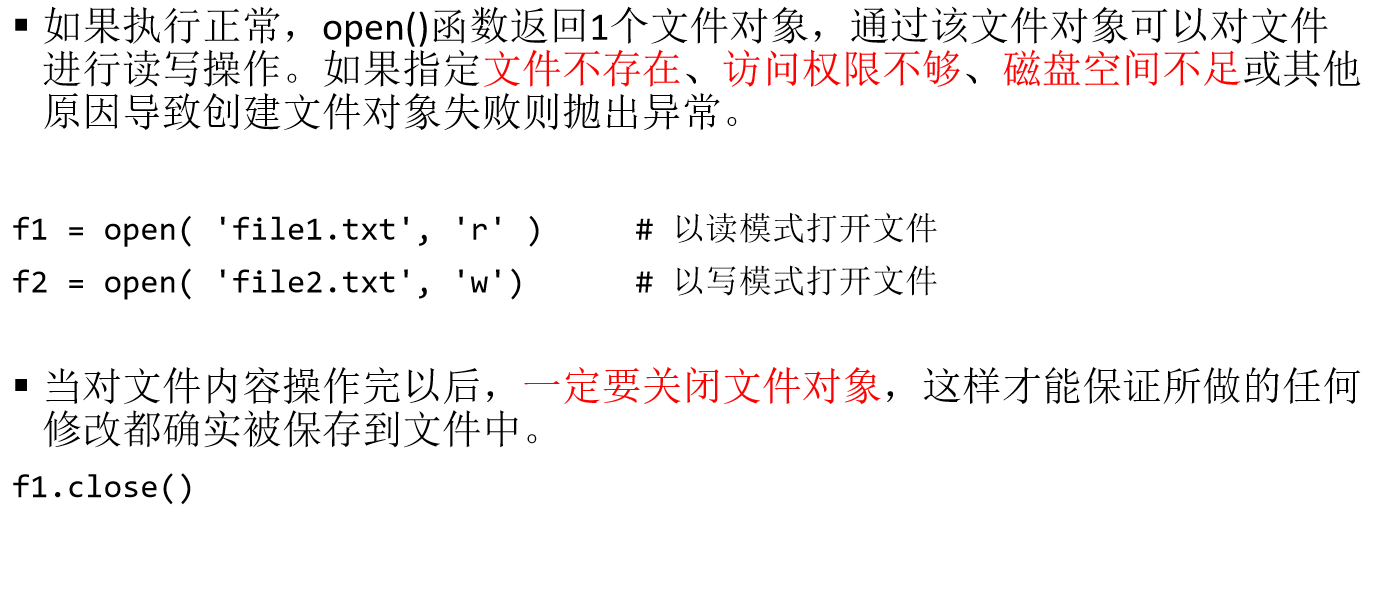

## 9.1.2  文件对象属性与常用方法


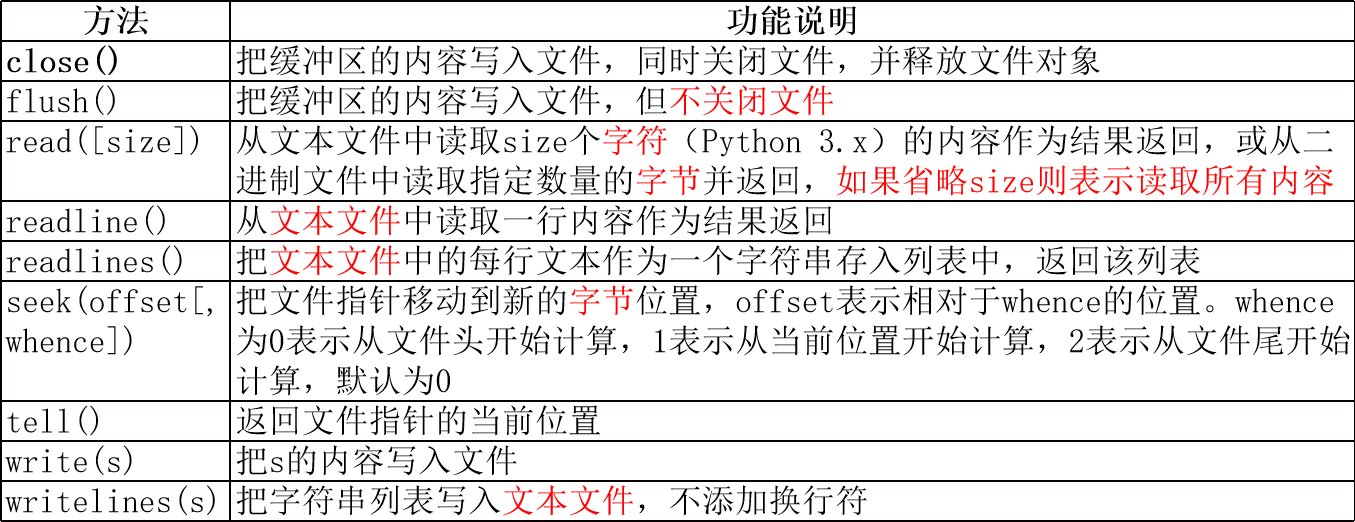

In [92]:
f1 = open('test3.txt','w')
s = 'We are friends.\n We are happy!\n I like apple.'
f1.write(s)
f1.close()

In [93]:
f1 = open('test3.txt','r+')
f1.readline()

'We are friends.\n'

In [94]:
f1.readlines()

[' We are happy!\n', ' I like apple.']

In [98]:
f1.seek(4)

4

In [99]:
f1.readline()

're friends.\n'

In [100]:
f1.readlines()

[' We are happy!\n', ' I like apple.']

In [101]:
f1.tell()

47

In [90]:
f1 = open('test2.txt','w')
s = ['We are friends.\n', 'We are happy!\n', 'I like apple']
f1.writelines(s)
f1.close()

In [91]:
f1 = open('test2.txt','r+')
f1.readlines()

['We are friends.\n', 'We are happy!\n', 'I like apple']

## 9.1.3  上下文管理语句with


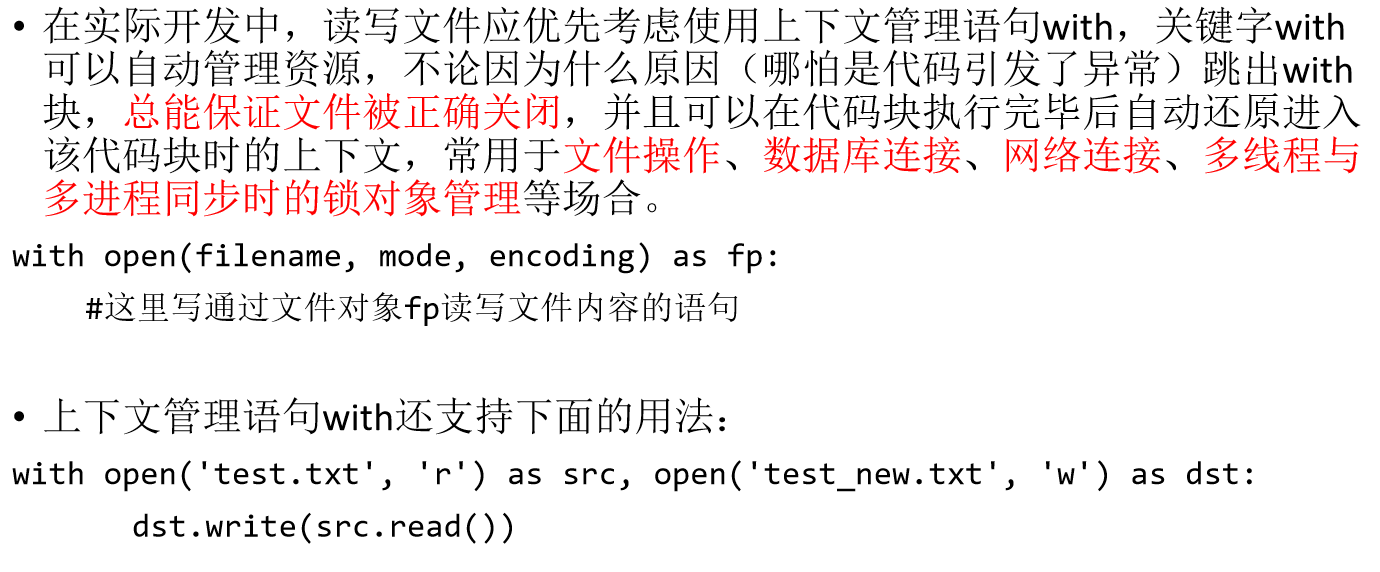

## 示例9-1   向文本文件中写入内容，然后再读出。

In [319]:
#s = '你好世界\n文本文件读取方法\n文本文件写入方法\n'
s='文本文件写入方法'
with open('sample.txt', 'w',encoding='utf8') as fp:    #默认使用cp936编码
    fp.write(s)

with open('sample.txt','r',encoding='utf8') as fp:         #默认使用cp936编码
    print(fp.read())

文本文件写入方法


In [320]:
s = '你好世界\n文本文件读取方法\n文本文件写入方法\n'
#s='文本文件写入方法'
with open('sample.txt', 'w') as fp:    #默认使用cp936编码
    fp.write(s)

with open('sample.txt','r') as fp:         #默认使用cp936编码
    print(fp.read())

你好世界
文本文件读取方法
文本文件写入方法



## 示例9-2   将一个CP936编码格式的文本文件中的内容全部复制到另一个使用UTF8编码的文本文件中。


In [269]:
def fileCopy(src, dst, srcEncoding, dstEncoding):
    with open(src, 'r', encoding=srcEncoding) as srcfp:
        with open(dst, 'w', encoding=dstEncoding) as dstfp:
            dstfp.write(srcfp.read())

fileCopy('sample.txt', 'sample_new.txt', 'cp936', 'utf8')

## 示例9-3   遍历并输出文本文件的所有行内容

In [323]:
s='你好世界\n文本文件读取方法\n文本文件写入方法\n'
with open('sample.txt', 'w',encoding='utf8') as fp:    
    fp.write(s)

with open('sample.txt','r',encoding='utf8') as fp:       
    print(fp.readlines())

with open('sample.txt',encoding='utf8') as fp:      
    for line in fp:                 #文件对象可以直接迭代
        print(line)

['你好世界\n', '文本文件读取方法\n', '文本文件写入方法\n']
你好世界

文本文件读取方法

文本文件写入方法



## 示例9-4   假设已有一个文本文件sample.txt，将其中指定的两个字符修改为测试。



In [325]:
with open('sample1.txt', 'w+',encoding='utf8') as fp:
    fp.write('文件阅读文件编辑方法')
    fp.seek(12)
    fp.write('测试')
    fp.seek(0)
    print(fp.read())

编辑方法


## 示例9-5  假设文件data.txt中有若干整数，所有整数之间使用英文逗号分隔，编写程序读取所有整数，将其按升序排序后再写入文本文件data_asc.txt中。


In [271]:
s = '123,56,78    \n 5,6,7   \n 88,99,100   \n'
with open('data.txt', 'w',encoding='utf8') as fp:    #默认使用cp936编码
    fp.write(s)

In [272]:
with open('data.txt', 'r',encoding='utf8') as fp:
    data = fp.readlines()                         #读取所有行
    #print(data)
data = [line.strip() for line in data]            #删除每行两侧的空白字符
data = ','.join(data)                             #合并所有行
data = data.split(',')                            #分隔得到所有数字字符串
#data = [element.split(',') for element in data]
#data = [x for y in data for x in y]
data

['123', '56', '78', '5', '6', '7', '88', '99', '100']

In [273]:
data = [int(item) for item in data]               #转换为数字
data.sort()                                       #升序排序
data = ','.join(map(str,data))                    #将结果转换为字符串
with open('data_asc.txt', 'w+') as fp:   #w+的区别 (w+ 会清空文件,r+不会清空文件)         #将结果写入文件
    fp.write(data)
    #print(fp.tell())
    fp.seek(0)
    for line in fp:
        print(line)

5,6,7,56,78,88,99,100,123


# 示例9-6   统计文本文件中最长行的长度和该行的内容。


In [207]:
with open('sample.txt',encoding='utf8') as fp:
    result = [0, '']
    for line in fp:
        t = len(line.strip())
        if t > result[0]:
            result = [t, line]
print(result)


[8, '文本文件写入方法']


## json模块

> ### json模块：是一种轻量级的数据交换格式。易于人们阅读和编写。
> ### 特点：json可以在不同语言之间交换数据的，而pickle只在python中使用。
> ### json模块提供了四个方法：dumps、dump、loads、load

json dumps（）——把数据类型转换成字符串；
json dump（）——把数据类型转换成字符串并存储在文件中；
json loads（）——把字符串转换成数据类型；
json load（）——把文件打开从字符串转换成数据类型；

## 示例9-7   使用标准库json进行数据交换。


In [208]:
import json
with open('test.txt', 'w') as fp:
    json.dump({'a':1, 'b':2, 'c':3}, fp) #写入文件

with open('test.txt', 'r') as fp:
    print(json.load(fp)) #从文件中读取

{'a': 1, 'b': 2, 'c': 3}


## 9.3  二进制文件操作案例精选


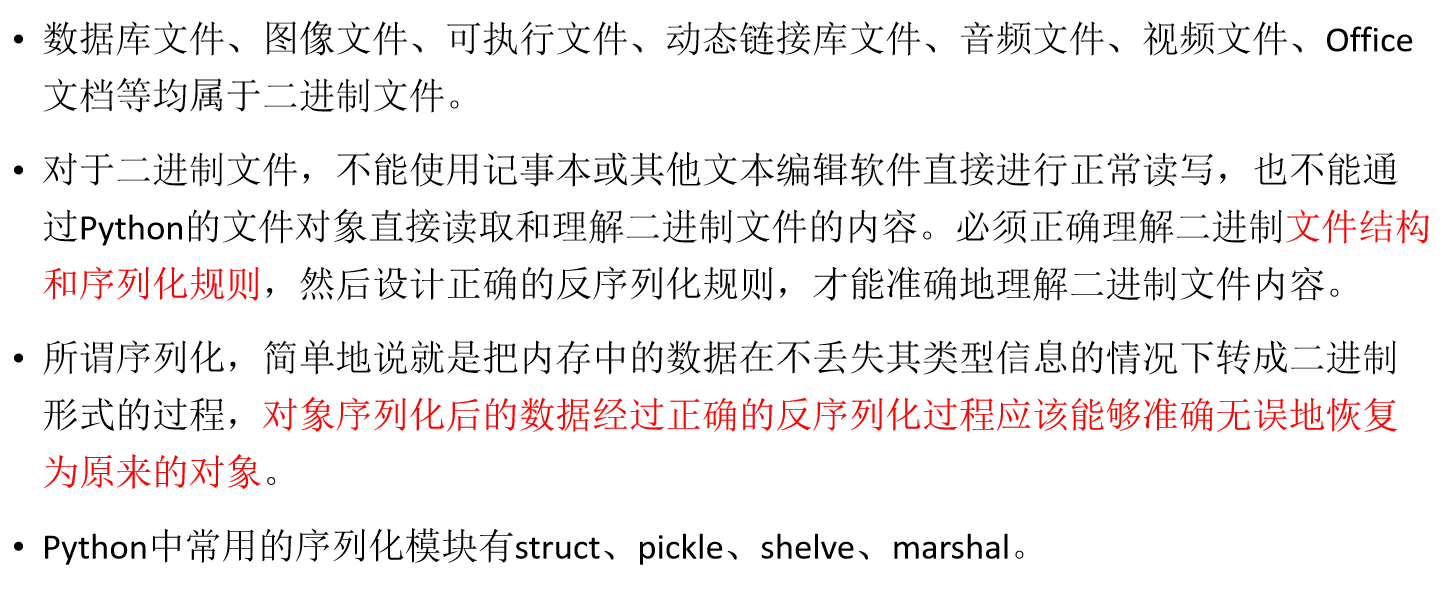

## 9.3.1  使用pickle模块读写二进制文件


pickle提供的dump()方法将数据进行序列化并写入文件，
load()方法读取二进制文件内容并进行反序列化，还原为原来的信息。

In [213]:
import pickle

i = 13000000
a = 99.056
s = '中国人民 123abc'
lst = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
tu = (-5, 10, 8)
coll = {4, 5, 6}
dic = {'a':'apple', 'b':'banana', 'g':'grape', 'o':'orange'}
data = (i, a, s, lst, tu, coll, dic)
with open('sample_pickle.dat', 'wb') as f:
    try:
        pickle.dump(len(data), f)        #要序列化的对象个数
        for item in data:
            pickle.dump(item, f)         #序列化数据并写入文件
    except:
        print('写文件异常')

with open('sample_pickle.dat', 'rb') as f:
    for i in range(pickle.load(f)):
        print(pickle.load(f)) 

13000000
99.056
中国人民 123abc
[[1, 2, 3], [4, 5, 6], [7, 8, 9]]
(-5, 10, 8)
{4, 5, 6}
{'a': 'apple', 'b': 'banana', 'g': 'grape', 'o': 'orange'}


In [218]:
with open('sample_pickle.dat', 'rb') as f:
    print(pickle.load(f)) #pickle.dump()每次序列化生成的字符串有独立的头尾
                          #pickle.load()只会读取一个完整的结果
    print(pickle.load(f))
    print(pickle.load(f))

7
13000000
99.056


### pickle提供的dumps()方法返回数据进行序列化之后的字节串形式，
### loads()方法读取二进制文件内容并进行反序列化，得到原始数据。

In [219]:
pickle.dumps([1,2,3])

b'\x80\x04\x95\x0b\x00\x00\x00\x00\x00\x00\x00]\x94(K\x01K\x02K\x03e.'

In [220]:
pickle.loads(_)

[1, 2, 3]

## 示例9-13   把文本文件test.txt中的所有信息使用pickle进行序列化并写入二进制文件test_pickle.dat。


In [221]:
import pickle

with open('test.txt') as src, open('test_pickle.dat', 'wb') as dest:
    for line in src:
        ##填空
        pickle.dump(line,dest)
        
with open('test_pickle.dat', 'rb') as fp:
    while True:
        try:
            print(pickle.load(fp))
        except:
            break


{"a": 1, "b": 2, "c": 3}


## 9.3.2  使用struct模块读写二进制文件


In [ ]:
Pickle模块主要用于对象的序列化和反序列化，
可以将Python对象转换为字节流以进行存储或传输。
（1）Pickle模块提供了将Python对象序列化和反序列化的功能，
可以将复杂的数据结构转换为字节流，以便存储到文件或在网络中传输。
（2）Pickle能够处理几乎所有的Python对象，包括自定义类的实例、函数、模块等。
（3）使用pickle模块，你可以将对象保存到文件中，以便稍后使用或共享给其他Python程序。

而Struct模块主要用于处理二进制数据，提供了打包和拆包的功能，
用于处理数据类型之间的转换和兼容性。
它们在处理数据的方式和应用场景上有所不同。
（1）Struct模块用于处理二进制数据，
它提供了一种将数据打包（pack）和拆包（unpack）为字符串的方式。
（2）Struct模块的主要目的是将Python的数据类型转换为C语言中的数据类型（bytes），
从而在不同平台上实现二进制数据的兼容性。
（3）Struct模块使用一种简单的格式字符串来指定数据的布局，
例如指定字节顺序、数据类型和数据大小等。

In [ ]:
pack()方法将对象指定的格式进行序列化
write()方法将序列化后的结果写入二进制文件
read()方法读取二进制文件的内容
unpack()方法反序列化得到原来的信息

In [228]:
struct.calcsize('?')#查看

1

In [222]:
import struct
# https://zhuanlan.zhihu.com/p/369110412
#https://blog.csdn.net/Robin_Pi/article/details/112233764
n = 1300000000
x = 96.45
b = True
s = 'a1@中国'
sn = struct.pack('if?', n, x, b) #序列化，i表示整数，f表示实数，?表示逻辑值
with open('sample_struct.dat', 'wb') as f:
    f.write(sn)
    f.write(s.encode())              #字符串需要编码为字节串再写入文件

with open('sample_struct.dat', 'rb') as f:
    sn = f.read(9)
    tu = struct.unpack('if?', sn)    #使用指定格式反序列化
    n, x, b1 = tu                    #序列解包
    print('n=',n, 'x=',x, 'b1=',b1)
    s = f.read(9)
    s = s.decode()                   #字符串解码
    print('s=', s)


n= 1300000000 x= 96.44999694824219 b1= True
s= a1@中国


In [131]:
n = 1300000000
x = 96.45
b = True
s = 'ab@中国'
sn = struct.pack('if?9s', n, x, b,s.encode()) #序列化，i表示整数，f表示实数，?表示逻辑值
with open('sample_struct.dat', 'wb') as f:
    f.write(sn)
    #f.write(s.encode()) 

with open('sample_struct.dat', 'rb') as f:
    sn = f.read(18)
    tu = struct.unpack('if?9s', sn)    #使用指定格式反序列化
    n, x, b1, s = tu                    #序列解包
    print('n=',n, 'x=',x, 'b1=',b1, 's1=',s.decode())
   

n= 1300000000 x= 96.44999694824219 b1= True s1= ab@中国


## 9.3.3  使用shelve模块操作二进制文件



In [ ]:
Python标准库shelve也提供了二进制文件操作的功能，
可以像字典赋值一样来写入二进制文件，
也可以像字典一样读取二进制文件。

In [494]:
import shelve
zhangsan = {'age':38, 'sex':'Male', 'address':'SDIBT'}
lisi = {'age':40, 'sex':'Male', 'qq':'1234567', 'tel':'7654321'}
with shelve.open('shelve_test.dat') as fp:
    fp['zhangsan'] = zhangsan      # 像操作字典一样把数据写入文件
    fp['lisi'] = lisi
    for i in range(5):
        fp[str(i)] = str(i)

with shelve.open('shelve_test.dat') as fp:
        print(fp['zhangsan'])                 #读取并显示文件内容
        print(fp['zhangsan']['age'])
        print(fp['lisi']['qq'])
        print(fp['3'])
        print(list(fp.items()))
       

{'age': 38, 'sex': 'Male', 'address': 'SDIBT'}
38
1234567
3
[('zhangsan', {'age': 38, 'sex': 'Male', 'address': 'SDIBT'}), ('lisi', {'age': 40, 'sex': 'Male', 'qq': '1234567', 'tel': '7654321'}), ('0', '0'), ('1', '1'), ('2', '2'), ('3', '3'), ('4', '4')]


## 9.3.4  其他常见类型二进制文件操作案例(选学)


## 示例9-16   使用扩展库openpyxl读写Excel 2007以及更高版本的文件。


In [229]:
import openpyxl
from openpyxl import Workbook
fn = r'test.xlsx'                          #文件名
wb = Workbook()                            #创建工作簿
ws = wb.create_sheet(title='你好，世界')    #创建工作表
ws['A1'] = '这是第一个单元格'                #单元格赋值
ws['B1'] = 3.1415926
wb.save(fn)                                 #保存Excel文件
wb = openpyxl.load_workbook(fn)             #打开已有的Excel文件
ws = wb.worksheets[1]                       #打开指定索引的工作表
print(ws['A1'].value)                       #读取并输出指定单元格的值
ws.append([1,2,3,4,5])                      #添加一行数据
ws.merge_cells('F2:F3')                     #合并单元格
ws['F2'] = "=sum(A2:E2)"                    #写入公式
for r in range(10,15):
    for c in range(3,8):
        ws.cell(row=r, column=c, value=r*c) #写入单元格数据
        wb.save(fn)

这是第一个单元格


In [231]:
#help(ws)

## 示例9-17   把记事本文件test.txt转换成Excel 2007+文件。假设test.txt文件中第一行为表头，从第二行开始是实际数据，并且表头和数据行中的不同字段信息都是用逗号分隔。


In [243]:
s = '努力生活、奋斗,成为最好的自己     \n 开心每一天   \n 回顾青春，不负韶华，不负自己   \n'
with open('test.txt', 'w+') as fp:    #默认使用cp936编码
    fp.write(s)
    for line in fp:
            line = line.strip().split(',')

In [245]:
from openpyxl import Workbook

def main(txtFileName):
    new_XlsxFileName = txtFileName[:-3] + 'xlsx'
    wb = Workbook()
    ws = wb.worksheets[0]
    with open(txtFileName) as fp:
        for line in fp:
            line = line.strip().split(',')
            print(line)
            ws.append(line)
    wb.save(new_XlsxFileName)
    return new_XlsxFileName

main('test.txt')


['努力生活、奋斗', '成为最好的自己']
['开心每一天']
['回顾青春，不负韶华，不负自己']


'test.xlsx'

## 示例9-19   提取docx文档中例题、插图和表格清单。


In [282]:
from docx import Document
import re

result = {'li':[], 'fig':[], 'tab':[]}
doc = Document(r'C:\Users\Yawen\Desktop\Python可以这样学.docx')

for p in doc.paragraphs:               #遍历文档所有段落
    t = p.text                         #获取每一段的文本
    if re.match('例\d+-\d+ ', t):      #例题
        result['li'].append(t)
    elif re.match('图\d+-\d+ ', t):    #插图
        result['fig'].append(t)
    elif re.match('表\d+-\d+ ', t):    #表格
        result['tab'].append(t)

for key in result.keys():              #输出结果
    print('='*30)
    for value in result[key]:
        print(value)

例1-1 解答
例2-1 解答
例1-3 解答
图2-1 解答
图3-1 解答
表2-1 解答


In [283]:
result

{'li': ['例1-1 解答', '例2-1 解答', '例1-3 解答'],
 'fig': ['图2-1 解答', '图3-1 解答'],
 'tab': ['表2-1 解答']}

## 示例：把某个文件夹下所有.txt文件里面的内容合并到一个新的.txt文件中

In [279]:
import os
content = ''
files=[filename for filename in os.listdir() if filename.endswith('.txt')]
print(files)

for filename in files[0:7]:
    with open (filename,'r',encoding='utf8') as fp:
        content = content + fp.read()        
       # print(content)
        
with open('all_data.txt','w+',encoding='utf8') as sp:
    sp.write(content)

['all_data.txt', 'data.txt', 'data1.txt', 'data_asc.txt', 'sample.txt', 'sample1.txt', 'sample_new.txt', 'temp.txt', 'test.txt', 'test1.txt', 'test2.txt', 'test3.txt', 'test4.txt', 'text.txt', '考场.txt']
